# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuratulainAzhar22/flyrank-ml-work/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the anonymized FlyRank dataset
df = pd.read_csv("content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nNumeric columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

Dataset shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

Numeric columns:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

### Distribution notes

I inspected the distributions of several search-performance and content signals before testing the assumptions behind the flags.

The selected fields include impressions, clicks, sessions, content age, average position, CTR, engagement rate, and trend percentage.

These metrics are expected to be unevenly distributed because a relatively small number of pages can account for a large share of search activity. I therefore use summary statistics and log-scaled plots where appropriate rather than relying only on the mean.

The analysis is descriptive and directional: it is used to understand the data before deciding which signals are useful for prioritization.


Distribution summary:


,count,mean,std,min,25%,50%,75%,max
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.0
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.0
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.0
content_age_days,30000.0,256.167800,132.707930,90.0,132.0,236.00,333.00,564.0
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,245.0
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,100.0
engagement_rate,30000.0,2.534520,8.310096,0.0,0.0,0.00,1.35,100.0
trend_pct,26612.0,-4.785969,473.861780,-100.0,-62.6,-33.50,0.00,44900.0



Missing values:
impressions_90d        0
clicks_90d             0
sessions_90d           0
content_age_days       0
avg_position           0
ctr                    0
engagement_rate        0
trend_pct           3388
dtype: int64


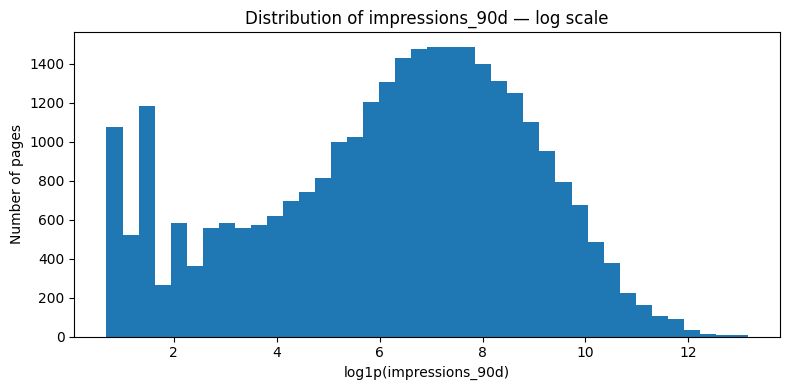

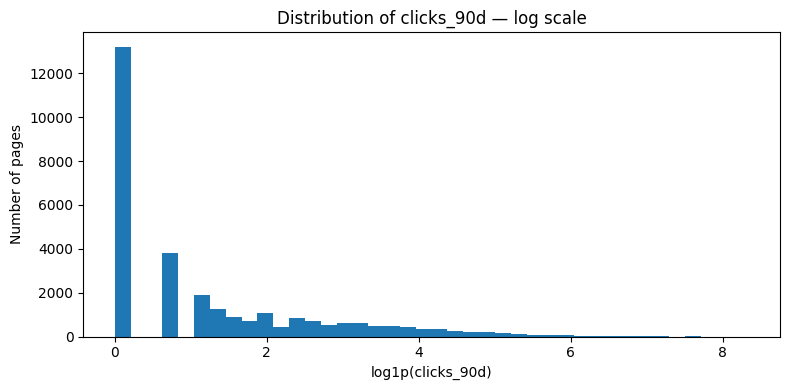

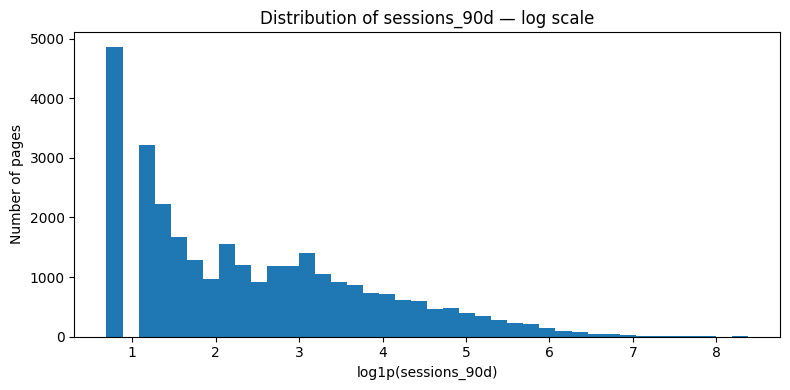

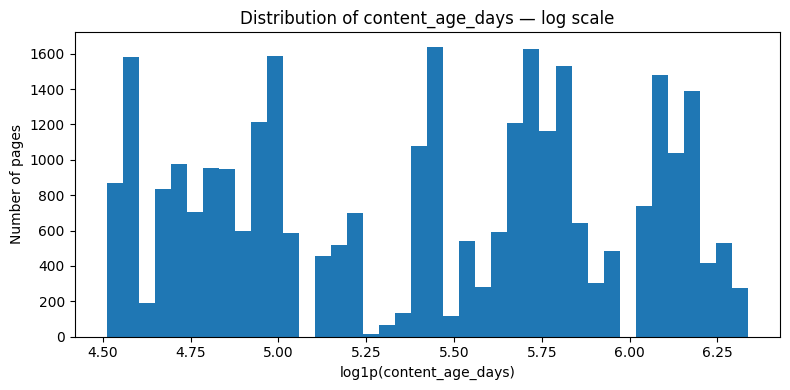

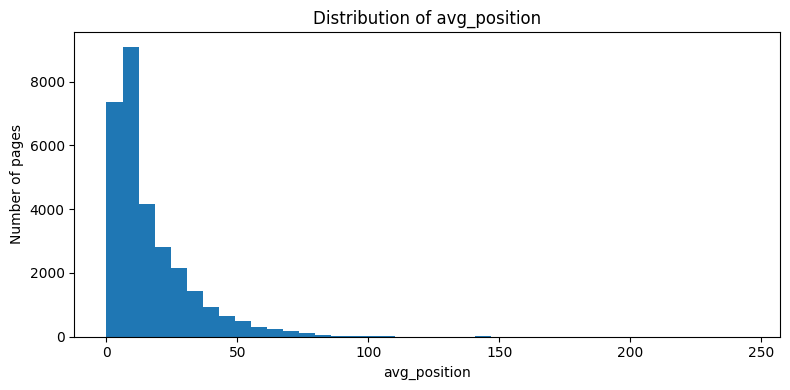

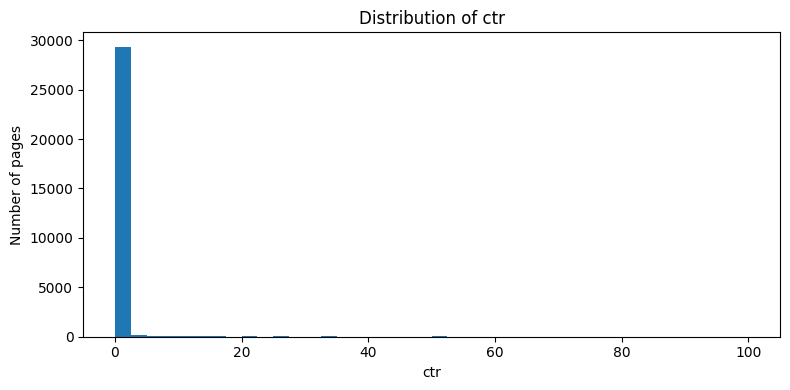

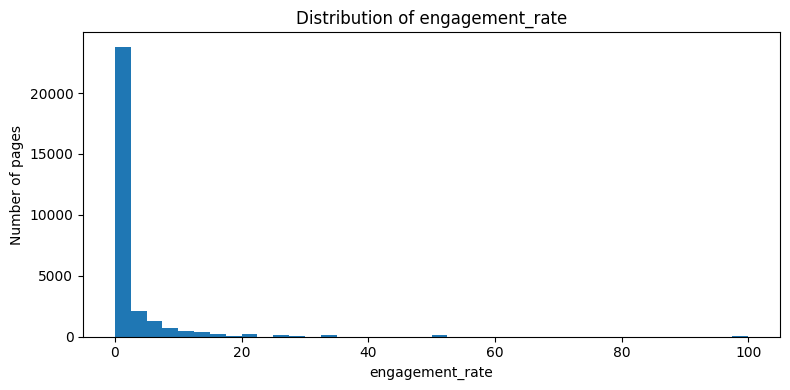

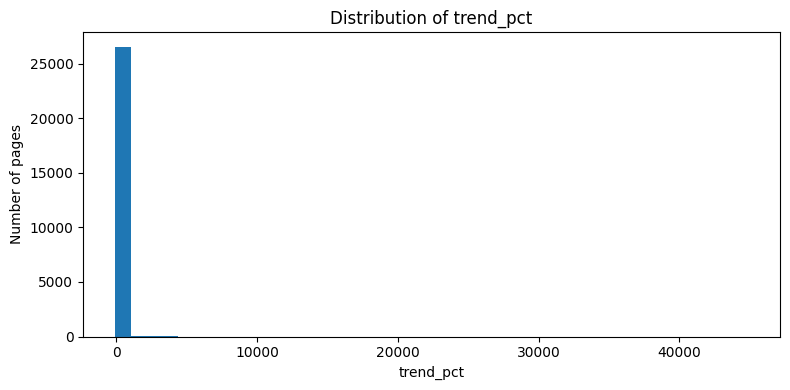

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 1 — Distributions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("content_refresh_anonymized.csv")

# Key numeric fields for the distribution audit
distribution_cols = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "avg_position",
    "ctr",
    "engagement_rate",
    "trend_pct"
]

# Summary statistics
distribution_summary = df[distribution_cols].describe().T

print("Distribution summary:")
display(distribution_summary)

# Missing-value check
print("\nMissing values:")
print(df[distribution_cols].isna().sum())

# Plot each distribution separately
for col in distribution_cols:
    plt.figure(figsize=(8, 4))
    values = pd.to_numeric(df[col], errors="coerce").dropna()

    if col in ["impressions_90d", "clicks_90d", "sessions_90d", "content_age_days"]:
        # Log1p helps visualize heavy-tailed variables
        plt.hist(np.log1p(values), bins=40)
        plt.xlabel(f"log1p({col})")
        plt.ylabel("Number of pages")
        plt.title(f"Distribution of {col} — log scale")
    else:
        plt.hist(values, bins=40)
        plt.xlabel(col)
        plt.ylabel("Number of pages")
        plt.title(f"Distribution of {col}")

    plt.tight_layout()
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal tests

I tested three signals that could plausibly indicate a content-refresh opportunity.

**Signal 1 — Content age:** older content may have a greater need for review.

**Signal 2 — Days since last update:** content that has not been updated for a longer period may have greater refresh potential.

**Signal 3 — Recent trend:** declining recent search activity may indicate that a page deserves investigation.

For each signal, I compare groups using observed search-performance measures rather than assuming that the relationship must exist.


In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 2 — Signal tests

# Create age/update/trend groups

df["age_group"] = pd.cut(
    df["content_age_days"],
    bins=[-1, 180, 365, 730, np.inf],
    labels=["<=180d", "181-365d", "366-730d", ">730d"]
)

df["update_group"] = pd.cut(
    df["days_since_last_update"],
    bins=[-1, 90, 180, 365, np.inf],
    labels=["<=90d", "91-180d", "181-365d", ">365d"]
)

# Trend direction is already categorical.
# Normalize text so grouping is consistent.
df["trend_direction_clean"] = (
    df["trend_direction"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# -------- Signal 1: Content age --------

age_test = (
    df.groupby("age_group", observed=True)
      .agg(
          pages=("content_id", "count"),
          median_impressions_90d=("impressions_90d", "median"),
          median_clicks_90d=("clicks_90d", "median"),
          median_ctr=("ctr", "median"),
          median_position=("avg_position", "median")
      )
      .reset_index()
)

print("SIGNAL 1 — Content age")
display(age_test)

# -------- Signal 2: Days since update --------

update_test = (
    df.groupby("update_group", observed=True)
      .agg(
          pages=("content_id", "count"),
          median_impressions_90d=("impressions_90d", "median"),
          median_clicks_90d=("clicks_90d", "median"),
          median_ctr=("ctr", "median"),
          median_position=("avg_position", "median")
      )
      .reset_index()
)

print("SIGNAL 2 — Days since last update")
display(update_test)

# -------- Signal 3: Trend direction --------

trend_test = (
    df.groupby("trend_direction_clean", dropna=False)
      .agg(
          pages=("content_id", "count"),
          median_impressions_90d=("impressions_90d", "median"),
          median_clicks_90d=("clicks_90d", "median"),
          median_ctr=("ctr", "median"),
          median_position=("avg_position", "median"),
          median_trend_pct=("trend_pct", "median")
      )
      .reset_index()
)

print("SIGNAL 3 — Trend direction")
display(trend_test)

SIGNAL 1 — Content age


,age_group,pages,median_impressions_90d,median_clicks_90d,median_ctr,median_position
0,<=180d,12272,720.0,1.0,0.08,9.4
1,181-365d,11368,640.5,1.0,0.06,10.8
2,366-730d,6360,842.5,1.0,0.07,14.0


SIGNAL 2 — Days since last update


,update_group,pages,median_impressions_90d,median_clicks_90d,median_ctr,median_position
0,<=90d,20655,472.0,1.0,0.04,10.0
1,91-180d,9171,1692.0,2.0,0.10,13.6
2,181-365d,169,16.0,0.0,0.00,7.0
3,>365d,5,2.0,0.0,0.00,7.5


SIGNAL 3 — Trend direction


,trend_direction_clean,pages,median_impressions_90d,median_clicks_90d,median_ctr,median_position,median_trend_pct
0,down,16262,961.0,1.0,0.08,11.3,-55.60
1,flat,1152,4.0,0.0,0.00,6.6,NaN
2,new,2236,3.0,0.0,0.00,0.0,NaN
3,stable,5962,1944.5,3.0,0.17,11.4,-3.80
4,up,4388,587.0,1.0,0.09,15.3,62.55


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?

*

### Flag-linked test

I tested the freshness-related signal because the dataset contains both `freshness_tier` and `days_since_last_update`.

The assumption being tested is that content with a longer time since its last update may deserve greater review priority.

Rather than assuming that the freshness flag is correct, I compare observed search-performance metrics across freshness groups.

The result is treated as directional evidence for prioritization, not proof that freshness causes a change in rankings.


In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 3 — Flag-linked freshness test

freshness_test = (
    df.groupby("freshness_tier", dropna=False)
      .agg(
          pages=("content_id", "count"),
          median_days_since_update=("days_since_last_update", "median"),
          median_impressions_90d=("impressions_90d", "median"),
          median_clicks_90d=("clicks_90d", "median"),
          median_ctr=("ctr", "median"),
          median_position=("avg_position", "median"),
          median_trend_pct=("trend_pct", "median")
      )
      .reset_index()
      .sort_values("median_days_since_update")
)

print("Freshness flag audit:")
display(freshness_test)

# Also inspect the relationship between freshness and trend direction
freshness_trend = pd.crosstab(
    df["freshness_tier"],
    df["trend_direction_clean"],
    normalize="index"
) * 100

print("\nTrend direction (%) within each freshness tier:")
display(freshness_trend.round(1))

Freshness flag audit:


,freshness_tier,pages,median_days_since_update,median_impressions_90d,median_clicks_90d,median_ctr,median_position,median_trend_pct
0,0-30,20480,20.0,470.0,1.0,0.04,9.9,-33.3
2,31-90,175,41.0,510.0,0.0,0.00,13.9,-38.5
3,91-180,9171,104.0,1692.0,2.0,0.10,13.6,-34.4
1,181+,174,211.0,15.5,0.0,0.00,7.0,-44.5



Trend direction (%) within each freshness tier:


trend_direction_clean,down,flat,new,stable,up
freshness_tier,,,,,
0-30,51.1,4.4,10.4,18.6,15.5
181+,47.1,9.2,14.4,13.8,15.5
31-90,58.9,0.6,4.0,14.9,21.7
91-180,61.1,2.6,0.8,22.9,12.6


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

### What this means in practice

A content team should not use age or freshness as a simple rule such as "old pages should always be refreshed first." The observed data suggests that freshness, trend, traffic, and search position provide different pieces of evidence, so they are more useful when combined in a prioritization model. The results are directional and should support human review rather than automatically deciding which pages to change.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.